# OH⁻ vs OH• Comparison
## Preamble

In [1]:
import warnings
from collections import Counter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from chempiler import ChempilerTrajectory, diffusive_window
from chempiler.vanhove import van_hove
from chempiler import van_hove_heatmap
from chempiler.vdos import read_vdos, smooth
from chempiler.state_engine import atom_hop

import tol_colors as tc
cset = tc.bright

plt.rcParams.update({
    'grid.alpha': 0.3,
    'font.size': 12,
    'axes.prop_cycle': plt.cycler(color=cset)
})

dt            = 0.5   # fs
dump_interval = 10
dt_per_frame  = dt * dump_interval * 1e-3  # ps per frame

LOGFILE_ANION   = '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/39_water_OH.log'
LOGFILE_RADICAL = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.log'
LOGFILE_WATER   = '../data/MACE-POLAR-1-M/40_water/40_water_polar.log'

TRAJFILE_ANION   = '../data/MACE-POLAR-1-M/39_water_OH/charged_singlet/39_water_OH.traj'
TRAJFILE_RADICAL = '../data/MACE-POLAR-1-M/39_water_OH/neutral_doublet/39_water_OH.traj'
TRAJFILE_WATER   = '../data/MACE-POLAR-1-M/40_water/40_water_polar.traj'

In [2]:
traj_anion = ChempilerTrajectory(TRAJFILE_ANION, mode='molecular', covalent_scale=0.8)
traj_anion.build(cache_file='tests/OH_dyn_cache.h5', persistence=3)

traj_radical = ChempilerTrajectory(TRAJFILE_RADICAL, mode='molecular', covalent_scale=0.8)
traj_radical.build(cache_file='tests/OH_rad_dyn_cache.h5', persistence=3)

traj_water = ChempilerTrajectory(TRAJFILE_WATER, mode='molecular', covalent_scale=0.8)
traj_water.build(cache_file='tests/40_water_cache.h5', persistence=3)

[Chempiler] loaded cache → tests/OH_dyn_cache.h5
[Chempiler] persistence=3: corrected 209 frames
[Chempiler] loaded cache → tests/OH_rad_dyn_cache.h5
[Chempiler] loaded cache → tests/40_water_cache.h5
[Chempiler] persistence=3: corrected 4 frames


## Species summary

In [3]:
systems = [('OH⁻', traj_anion), ('OH•', traj_radical), ('H₂O', traj_water)]
all_formulas = sorted(
    {f for _, t in systems for f in t.summary()},
    key=lambda f: -sum(t.summary().get(f, 0) for _, t in systems)
)
rows = []
for lbl, traj in systems:
    s = traj.summary()
    rows.append({f: s.get(f, 0) for f in all_formulas})
pd.DataFrame(rows, index=[lbl for lbl, _ in systems])[all_formulas]

,H2O,HO,H3O2,H5O3
OH⁻,778392,18358,1639,4
OH•,780039,20001,0,0
H₂O,800040,0,0,0


The OH⁻ system produces transient H₃O₂ and H₅O₃ intermediates. The OH• system contains only HO and H₂O throughout, with no species transitions detected.

## Water diffusion (MSD)

D  OH⁻ : 1.260e-09 m²/s
D  OH• : 7.320e-10 m²/s
D  H₂O : 7.540e-10 m²/s


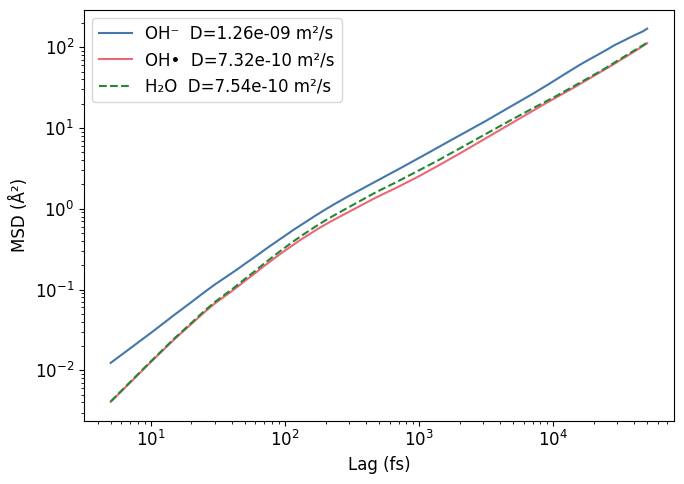

In [4]:
lags_a, msd_a, _ = traj_anion.msd('H2O',  dt=dt * dump_interval)
lags_r, msd_r, _ = traj_radical.msd('H2O', dt=dt * dump_interval)
lags_w, msd_w, _ = traj_water.msd('H2O',  dt=dt * dump_interval)

mask_a, _, _, _ = diffusive_window(lags_a, msd_a)
mask_r, _, _, _ = diffusive_window(lags_r, msd_r)
mask_w, _, _, _ = diffusive_window(lags_w, msd_w)

def fit_D(lags, msd, mask):
    c = np.polyfit(lags[mask], msd[mask], 1)
    return c[0] / 6 * 1e-20 / (dt * dump_interval * 1e-15)

D_a = fit_D(lags_a, msd_a, mask_a)
D_r = fit_D(lags_r, msd_r, mask_r)
D_w = fit_D(lags_w, msd_w, mask_w)

print(f'D  OH⁻ : {D_a:.3e} m²/s')
print(f'D  OH• : {D_r:.3e} m²/s')
print(f'D  H₂O : {D_w:.3e} m²/s')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(lags_a, msd_a, color=cset[0], lw=1.5, label=f'OH⁻  D={D_a:.2e} m²/s')
ax.plot(lags_r, msd_r, color=cset[1], lw=1.5, label=f'OH•  D={D_r:.2e} m²/s')
ax.plot(lags_w, msd_w, color=cset[2], lw=1.5, ls='--', label=f'H₂O  D={D_w:.2e} m²/s')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Lag (fs)')
ax.set_ylabel('MSD (Å²)')
ax.legend()
plt.tight_layout()

H₂O diffusion in the OH⁻ system (D = 1.28×10⁻⁹ m²/s) is ~70 % higher than in pure water (7.54×10⁻¹⁰ m²/s). The OH• system gives D = 7.32×10⁻¹⁰ m²/s, within 3 % of pure water.

## Van Hove self-correlation
### Water

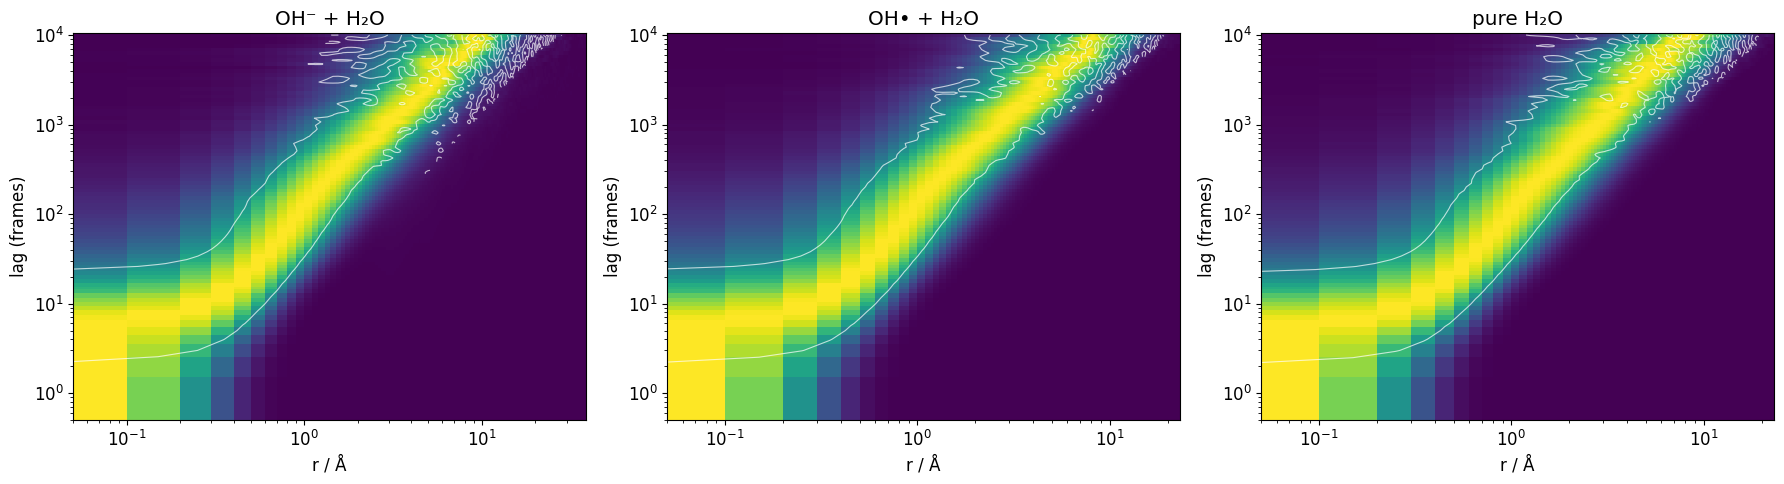

In [3]:
lag_vals_hm = np.unique(np.geomspace(1, 10000, 100).round().astype(int))

r_a, p_a = van_hove(traj_anion.frames,   'H2O', lags=lag_vals_hm, kde=True, kde_bandwidth=0.2)
r_r, p_r = van_hove(traj_radical.frames, 'H2O', lags=lag_vals_hm, kde=True, kde_bandwidth=0.2)
r_w, p_w = van_hove(traj_water.frames,   'H2O', lags=lag_vals_hm, kde=True, kde_bandwidth=0.2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
van_hove_heatmap(r_a, p_a, lag_vals_hm, ax=axes[0])
van_hove_heatmap(r_r, p_r, lag_vals_hm, ax=axes[1])
van_hove_heatmap(r_w, p_w, lag_vals_hm, ax=axes[2])

for ax, title in zip(axes, ['OH⁻ + H₂O', 'OH• + H₂O', 'pure H₂O']):
    ax.set_title(title)
    ax.set_xlabel('r / Å')
    ax.set_ylabel('lag (frames)')
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.tight_layout()

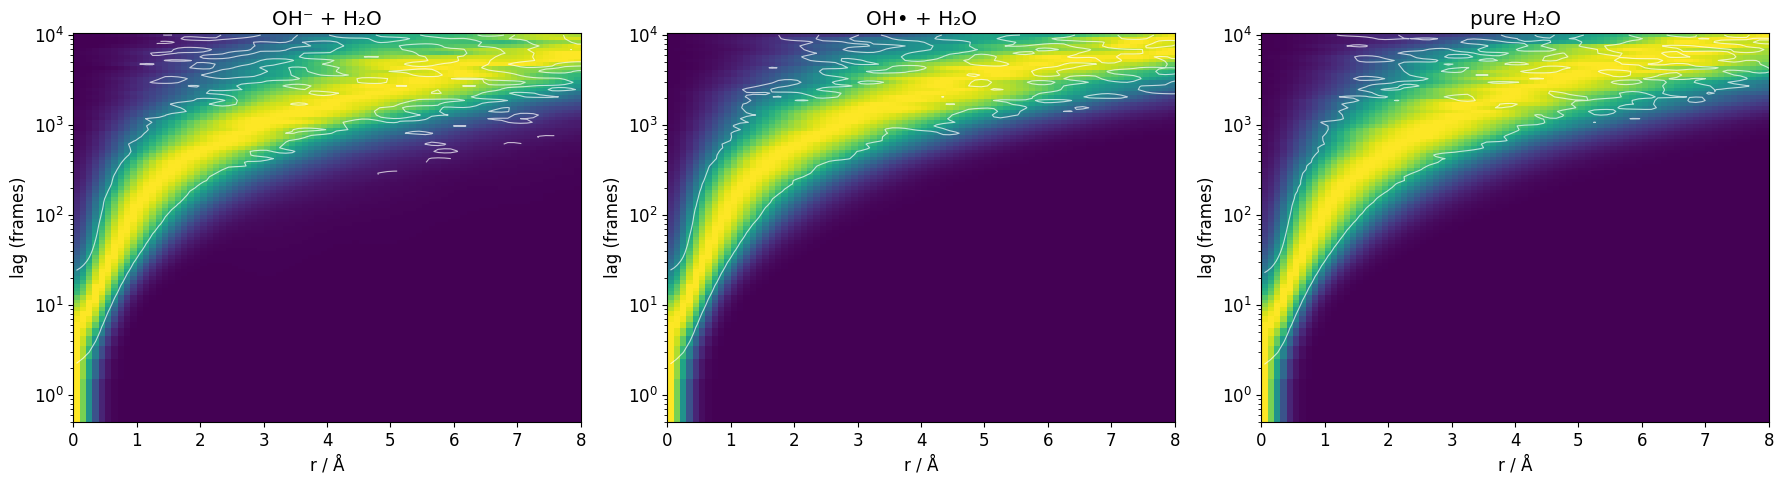

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
van_hove_heatmap(r_a, p_a, lag_vals_hm, ax=axes[0])
van_hove_heatmap(r_r, p_r, lag_vals_hm, ax=axes[1])
van_hove_heatmap(r_w, p_w, lag_vals_hm, ax=axes[2])

for ax, title in zip(axes, ['OH⁻ + H₂O', 'OH• + H₂O', 'pure H₂O']):
    ax.set_title(title)
    ax.set_xlabel('r / Å')
    ax.set_ylabel('lag (frames)')
    ax.set_xlim(0,8)
plt.tight_layout()

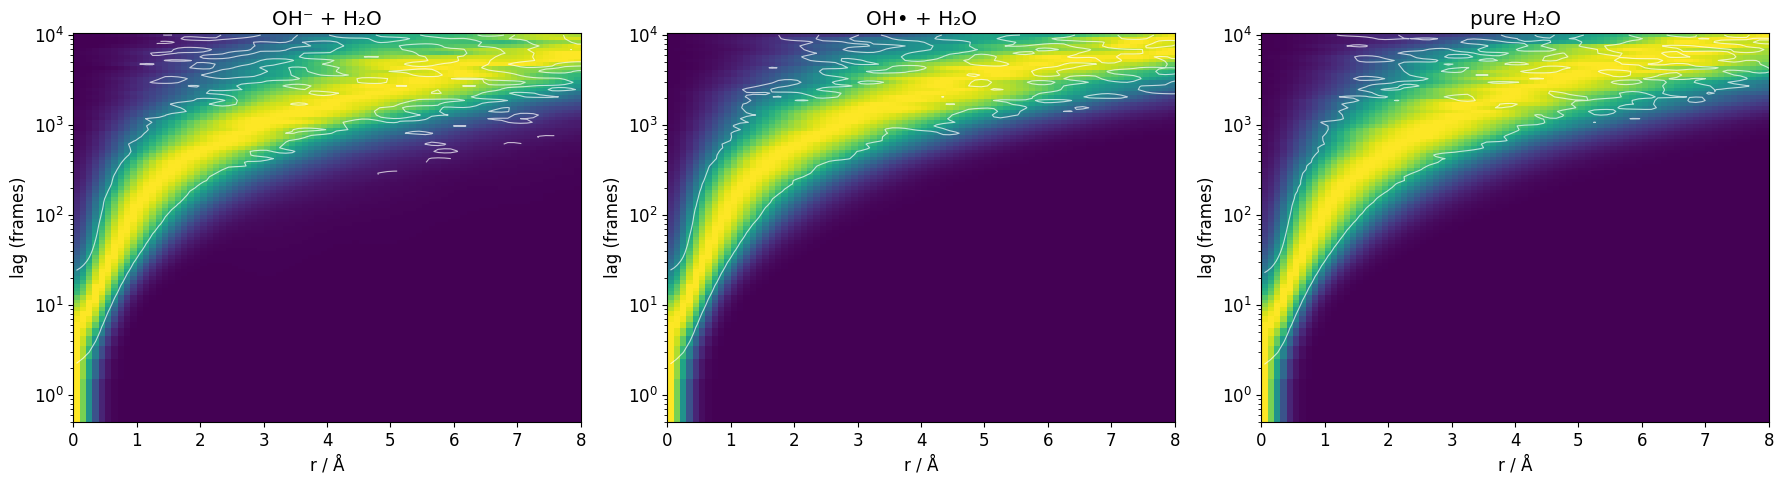

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
van_hove_heatmap(r_a, p_a, lag_vals_hm, ax=axes[0])
van_hove_heatmap(r_r, p_r, lag_vals_hm, ax=axes[1])
van_hove_heatmap(r_w, p_w, lag_vals_hm, ax=axes[2])

for ax, title in zip(axes, ['OH⁻ + H₂O', 'OH• + H₂O', 'pure H₂O']):
    ax.set_title(title)
    ax.set_xlabel('r / Å')
    ax.set_ylabel('lag (frames)')
    ax.set_xlim(0,8)
plt.tight_layout()

The OH⁻ panel shows peak positions shifted to larger r at equivalent lags, consistent with faster H₂O diffusion. The OH• and pure water panels are nearly identical.

### OH

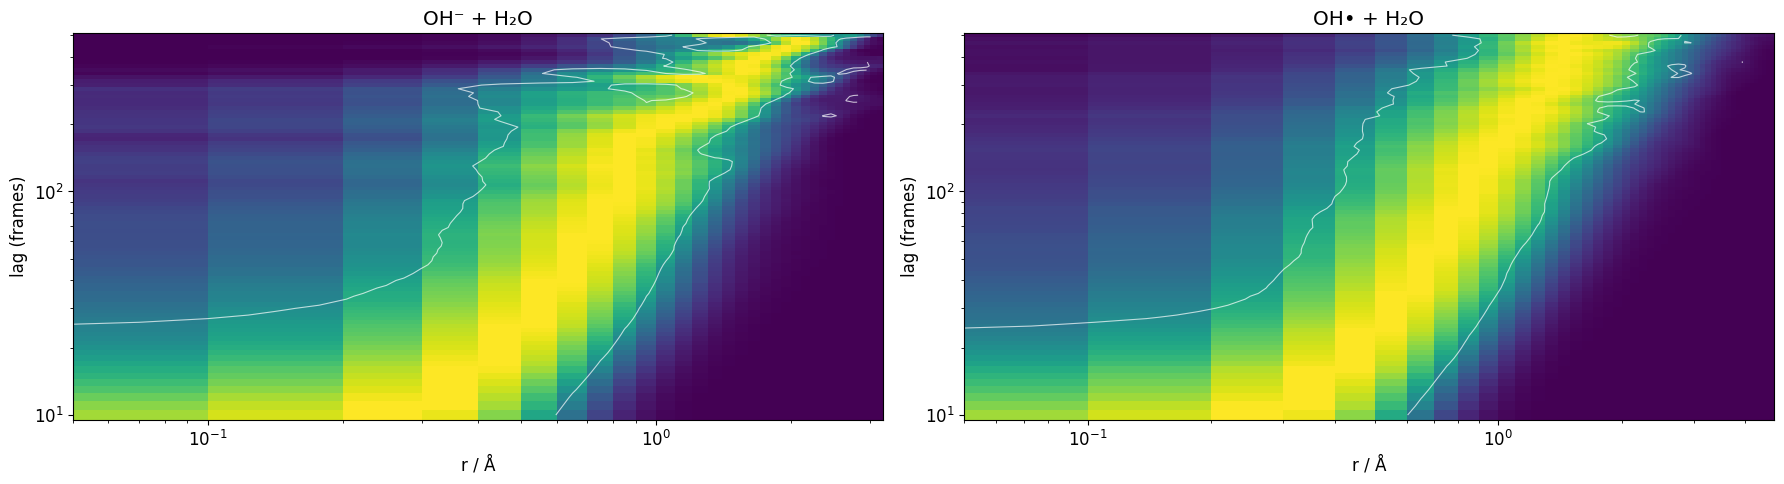

In [35]:
lag_vals_hm = np.unique(np.geomspace(10, 500, 100).round().astype(int))

r_a, p_a = van_hove(traj_anion.frames,   'HO', lags=lag_vals_hm, kde=True, kde_bandwidth=0.2)
r_r, p_r = van_hove(traj_radical.frames, 'HO', lags=lag_vals_hm, kde=True, kde_bandwidth=0.2)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
van_hove_heatmap(r_a, p_a, lag_vals_hm, ax=axes[0])
van_hove_heatmap(r_r, p_r, lag_vals_hm, ax=axes[1])

for ax, title in zip(axes, ['OH⁻ + H₂O', 'OH• + H₂O']):
    ax.set_title(title)
    ax.set_xlabel('r / Å')
    ax.set_ylabel('lag (frames)')
    ax.set_xscale('log')
    ax.set_yscale('log')
plt.tight_layout()

In the cell below, the OH- ends with bimodal van Hove curves. There is much noise but this is an indicator of the Grotthus mechanism since it occurs near 2.8 Å.

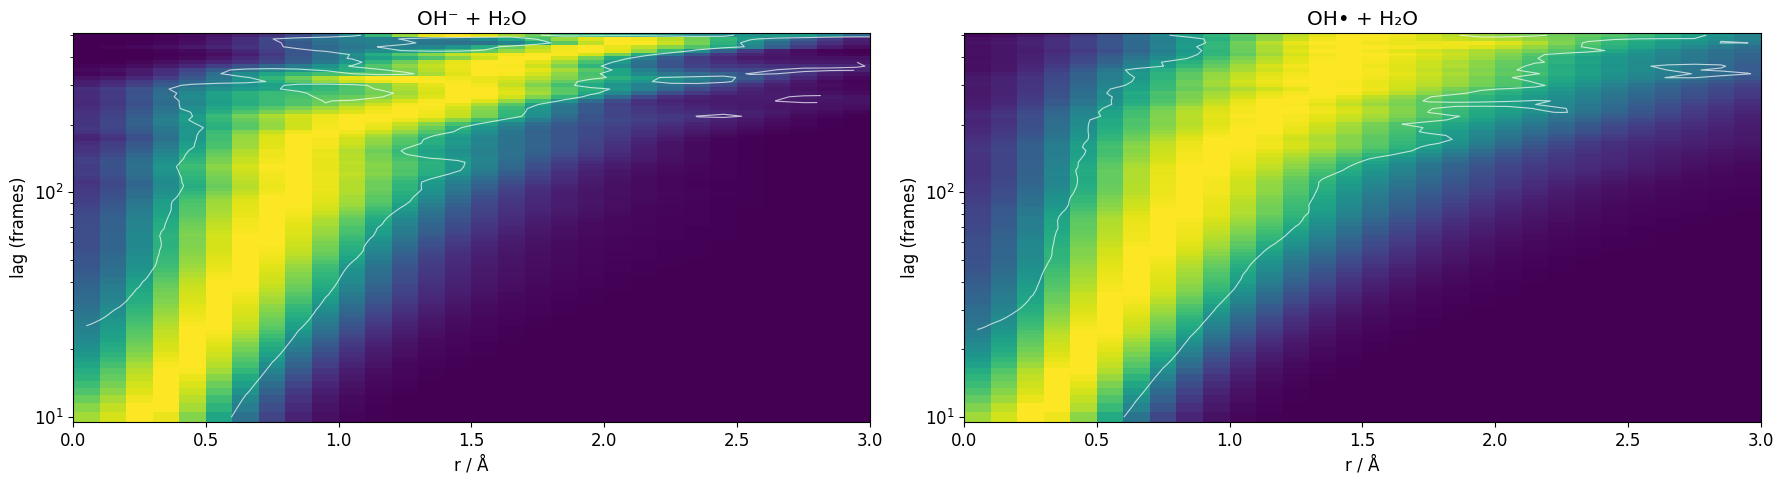

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
van_hove_heatmap(r_a, p_a, lag_vals_hm, ax=axes[0])
van_hove_heatmap(r_r, p_r, lag_vals_hm, ax=axes[1])

for ax, title in zip(axes, ['OH⁻ + H₂O', 'OH• + H₂O']):
    ax.set_title(title)
    ax.set_xlabel('r / Å')
    ax.set_ylabel('lag (frames)')
    #ax.set_xscale('log')
    ax.set_xlim(0,3)
plt.tight_layout()

## VDOS

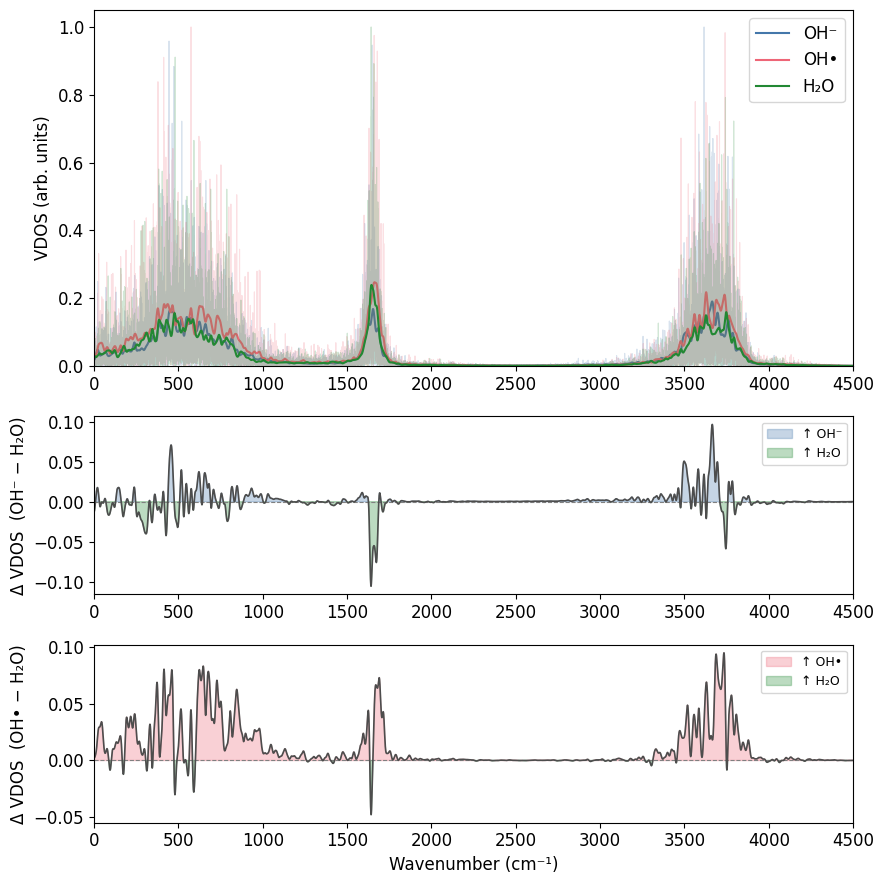

In [56]:
wn,  vdos_a = read_vdos(LOGFILE_ANION,   dt=dt)
_,   vdos_r = read_vdos(LOGFILE_RADICAL, dt=dt)
_,   vdos_w = read_vdos(LOGFILE_WATER,   dt=dt)

mask = (wn >= 0) & (wn <= 4500)
wn_m  = wn[mask]
sigma = 20

na = vdos_a[mask] / vdos_a[mask].max()
nr = vdos_r[mask] / vdos_r[mask].max()
nw = vdos_w[mask] / vdos_w[mask].max()

fig, axes = plt.subplots(3, 1, figsize=(9, 9),
                          gridspec_kw={'height_ratios': [2, 1, 1]})

for arr, label, color in [(na, 'OH⁻', cset[0]),
                           (nr, 'OH•', cset[1]),
                           (nw, 'H₂O', cset[2])]:
    axes[0].plot(wn_m, arr, color=color, alpha=0.2, lw=0.8)
    axes[0].plot(wn_m, smooth(arr, sigma), color=color, lw=1.5, label=label)
axes[0].set_xlim(0, 4500)
axes[0].set_ylim(0)
axes[0].set_ylabel('VDOS (arb. units)')
axes[0].legend()

for ax, diff, lp, ln, ylabel in [
        (axes[1], smooth(na - nw, sigma),
         '↑ OH⁻', '↑ H₂O', 'Δ VDOS  (OH⁻ − H₂O)'),
        (axes[2], smooth(nr - nw, sigma),
         '↑ OH•', '↑ H₂O', 'Δ VDOS  (OH• − H₂O)'),
]:
    c_pos = cset[0] if 'OH⁻' in lp else cset[1]
    ax.axhline(0, color='0.5', lw=0.8, ls='--')
    ax.plot(wn_m, diff, color='0.3', lw=1.2)
    ax.fill_between(wn_m, diff, 0, where=diff > 0, color=c_pos,   alpha=0.3, label=lp)
    ax.fill_between(wn_m, diff, 0, where=diff < 0, color=cset[2], alpha=0.3, label=ln)
    ax.set_xlim(0, 4500)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
axes[2].set_xlabel('Wavenumber (cm⁻¹)')
plt.tight_layout()

The OH⁻ difference spectrum shows enhanced O–H stretch intensity (~3200–3600 cm⁻¹) and reduced H–O–H bending intensity (~1600 cm⁻¹) relative to pure water. The character and magnitude of the OH• difference are visible in the lower panel.

---
## 1 — HO species lifetime

                             OH•           OH•
Segments                     245             1
Coverage                   91.8%        100.0%
Median (frames)               35         20001
Max (frames)                 570         20001


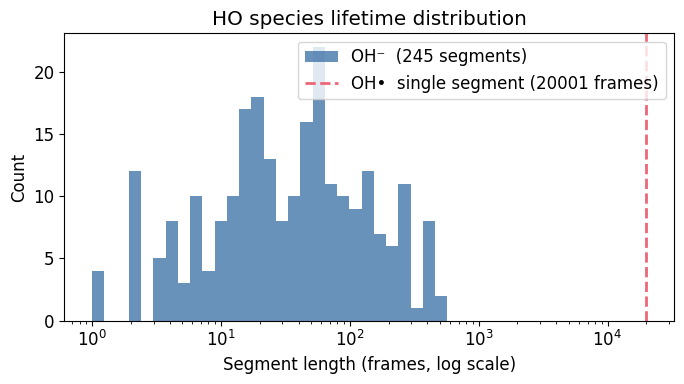

In [8]:
ho_segs_a = traj_anion.lifetime_segments('HO')
ho_segs_r = traj_radical.lifetime_segments('HO')

segs_a = np.array([e - s for s, e in ho_segs_a])
segs_r = np.array([e - s for s, e in ho_segs_r])

print(f"{'':18s}  {'OH•':>12s}  {'OH•':>12s}")
print(f"{'Segments':18s}  {len(ho_segs_a):>12d}  {len(ho_segs_r):>12d}")
print(f"{'Coverage':18s}  {100*segs_a.sum()/len(traj_anion.frames):>11.1f}%  "
      f"{100*segs_r.sum()/len(traj_radical.frames):>11.1f}%")
print(f"{'Median (frames)':18s}  {int(np.median(segs_a)):>12d}  {int(np.median(segs_r)):>12d}")
print(f"{'Max (frames)':18s}  {int(segs_a.max()):>12d}  {int(segs_r.max()):>12d}")

fig, ax = plt.subplots(figsize=(7, 4))
bins = np.logspace(0, np.log10(segs_a.max() + 1), 30)
ax.hist(segs_a, bins=bins, color=cset[0], alpha=0.8,
        label=f'OH\u207b  ({len(ho_segs_a)} segments)')
ax.axvline(len(traj_radical.frames), color=cset[1], lw=2, ls='--',
           label=f'OH\u2022  single segment ({len(traj_radical.frames)} frames)')
ax.set_xscale('log')
ax.set_xlabel('Segment length (frames, log scale)')
ax.set_ylabel('Count')
ax.set_title('HO species lifetime distribution')
ax.legend()
plt.tight_layout()

OH⁻ exists in 245 discrete segments with a median lifetime of 32 frames (0.16 ps), indicating repeated protonation–deprotonation cycles. OH• persists as a single uninterrupted segment for the full 100 ps trajectory.

---
## 2 — Proton transfer kinetics

OH⁻     hops= 244  0.0122/frame  (2.44 ps⁻¹)
OH•     hops=   0  0.0000/frame  (0.00 ps⁻¹)
H₂O     hops=   0  0.0000/frame  (0.00 ps⁻¹)


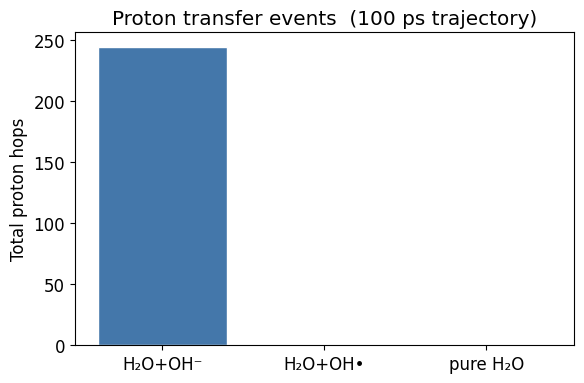

In [10]:
result_a = atom_hop(traj_anion.frames)
result_r = atom_hop(traj_radical.frames)
result_w = atom_hop(traj_water.frames)

for label, res, traj in [('OH\u207b', result_a, traj_anion),
                          ('OH\u2022', result_r, traj_radical),
                          ('H\u2082O',  result_w, traj_water)]:
    n    = res['n_transitions']
    rate = n / len(traj.frames)
    print(f'{label:6s}  hops={n:>4d}  {rate:.4f}/frame  ({rate/dt_per_frame:.2f} ps\u207b\u00b9)')

labels_bar = ['H\u2082O+OH\u207b', 'H\u2082O+OH\u2022', 'pure H\u2082O']
n_hops_bar = [result_a['n_transitions'], result_r['n_transitions'], result_w['n_transitions']]
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels_bar, n_hops_bar, color=[cset[0], cset[1], cset[2]], edgecolor='white')
ax.set_ylabel('Total proton hops')
ax.set_title('Proton transfer events  (100 ps trajectory)')
plt.tight_layout()

The OH⁻ system records 244 proton-transfer events over 100 ps (rate 2.44 ps⁻¹). This number is consistent with the number of segements that OH- is part of and, as a result, no other spurious reactions occur within the sytem during the simulation.

No hops are detected in the OH• system or the pure water reference.